## Visualizing Coordinate Precision on an OpenStreetMap Base


#### Adapted from a post by at Volodymyr Agafonkin at https://observablehq.com/@mourner/latitude-and-longitude-precision

In [9]:
import math
from IPython.display import HTML

def lng_to_px(lng, zoom):
    return 256 * (1 << zoom) * (lng / 360.0 + 0.5)

def lat_to_py(lat, zoom):
    return 256 * (1 << zoom) * (1 - math.log(math.tan(math.pi * (0.25 + lat / 360.0))) / math.pi) / 2.0

def osm_map(lng, lat, zoom, w=800, h=400, precision=None, auto_zoom=False):
    rounded_lng = lng
    rounded_lat = lat
    if precision is not None:
        delta = 0.5 * (10 ** (-precision))
        rounded_lng = round(lng, precision)
        rounded_lat = round(lat, precision)
        min_lng = rounded_lng - delta
        max_lng = rounded_lng + delta
        min_lat = rounded_lat - delta
        max_lat = rounded_lat + delta

        if auto_zoom:
            factor = 0.8
            delta_proj_x = (max_lng - min_lng) / 360.0
            def proj(l):
                return (1 - math.log(math.tan(math.pi * (0.25 + l / 360.0))) / math.pi) / 2.0
            delta_proj_y = proj(min_lat) - proj(max_lat)

            if delta_proj_x > 0:
                z_x = math.log2(w * factor / 256.0 / delta_proj_x)
            else:
                z_x = 0
            if delta_proj_y > 0:
                z_y = math.log2(h * factor / 256.0 / delta_proj_y)
            else:
                z_y = 0
            z = min(z_x, z_y)
            zoom = max(0, min(18, math.floor(z)))

    center_x = lng_to_px(rounded_lng, zoom)
    center_y = lat_to_py(rounded_lat, zoom)

    x = int(center_x - w / 2)
    y = int(center_y - h / 2)

    ty_min = y // 256
    tx_min = x // 256
    ty_max = ((y + h - 1) // 256) + 1
    tx_max = ((x + w - 1) // 256) + 1

    result = f'<div style="width:{w}px;height:{h}px;position:relative;overflow:hidden">'

    for ty in range(ty_min, ty_max):
        for tx in range(tx_min, tx_max):
            result += f'<img src="https://tile.osm.org/{zoom}/{tx}/{ty}.png" style="position:absolute;left:{tx*256 - x}px;top:{ty*256 - y}px">'

    if precision is not None:
        view_left = center_x - w / 2.0
        view_top = center_y - h / 2.0

        box_left = lng_to_px(min_lng, zoom)
        box_right = lng_to_px(max_lng, zoom)
        box_top = lat_to_py(max_lat, zoom)
        box_bottom = lat_to_py(min_lat, zoom)

        rel_left = box_left - view_left
        rel_top = box_top - view_top
        box_w = box_right - box_left
        box_h = box_bottom - box_top

        result += f'<div style="position:absolute;left:{rel_left}px;top:{rel_top}px;width:{box_w}px;height:{box_h}px;border:2px solid red;box-sizing:border-box;"></div>'

    result += '<div style="position:absolute;bottom:0;right:0;font:11px sans-serif;background:#fffa;padding:1px 5px">&copy; <a href="https://osm.org/copyright">OpenStreetMap</a> contributors</div></div>'
    return result

# Example usage for different precisions
lng = -0.124572
lat = 51.500743

# Coordinates for Montana State University


for p in range(0, 7):
    display(HTML(f"<h4>Precision: {p} decimal places</h4>"))
    display(HTML(osm_map(lng, lat, zoom=0, precision=p, auto_zoom=True)))  # zoom=0 is dummy, auto_zoom will set it

In [6]:
!pip install qrcode

DEPRECATION: Loading egg at /opt/conda/lib/python3.11/site-packages/tflite_model_maker-0.3.4-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


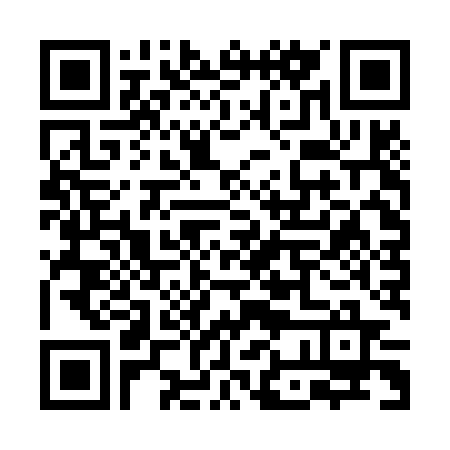

In [7]:
import qrcode
from IPython.display import Image

# URL to encode
url = "https://sscmsu.maps.arcgis.com/home/notebook/notebook.html?id=96c0070fea7a480caada25b65842e232"

# Generate QR code
qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_L,
    box_size=10,
    border=4,
)
qr.add_data(url)
qr.make(fit=True)

# Create an image from the QR Code instance
qr_image = qr.make_image(fill_color="black", back_color="white")

# Save the image (optional, for local use)
qr_image.save("qrcode.png")

# Display the QR code in the notebook
display(Image(filename="qrcode.png"))